# MS_DSA vs structural features (v2 tables)

Same plots as `eval2.ipynb`, made from the annotated v2 runs in `data/ms_dsa/evaluation1/runs/`
(built by `dsa.ms_dsa.evaluation1.build_annotations_v2`). Plotting functions: `dsa.ms_dsa.evaluation1.plots`.

Useful columns of each run table:
- MS_DSA: `MS_DSA` (all charge states), `MS_DSA_shared_charges` (charge states measured in both channels)
- flags: `channel_absent`, `no_shared_charges`, `zero_area`, `zero_area_shared`
- monomer SASA: `asa_nz_{avg,min,max}`, `rel_asa_{avg,min,max}`
- multimer SASA: `asa_nz_multimer_mean_{avg,min,max}`, `asa_nz_multimer_min_min`
- contacts: `inter_chain_pdb`, `intra_chain_pdb`, `intra_chain_alphafold`, `{bond_type}_{pdb,alphafold}`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dsa.ms_dsa.evaluation1.ms_dsa_annotator import MSDSAAnnotator
from dsa.ms_dsa.evaluation1.plots import plot_dsa_vs_sasa_with_binding_annotation, binned_histogram, plot_runs

plt.rcParams.update({"font.size": 8, "figure.dpi": 100})

RUN_INDICES = range(5)
ms_dsa_by_run = {run_index: MSDSAAnnotator.load_run(run_index) for run_index in RUN_INDICES}
ms_dsa_by_run[0].head()

,peptide_seq,Run,Run.Index,MS_DSA,MS_DSA_shared_charges,Protein.Names,Genes,Protein.Ids,Protein.Group,channel_absent,...,asa_nz_pdb_intra_covalent_isopeptide_max_max,asa_nz_pdb_intra_covalent_isopeptide_min_min,asa_nz_pdb_intra_covalent_isopeptide_mean_avg,asa_nz_pdb_intra_any_bond_max_max,asa_nz_pdb_intra_any_bond_min_min,asa_nz_pdb_intra_any_bond_mean_avg,asa_nz_pdb_no_contact_max_max,asa_nz_pdb_no_contact_min_min,asa_nz_pdb_no_contact_mean_avg,peptide_mapped
0,AAAAVEPDVVVKR,2025-12-02_SS_CPP_qcmethod_30nce,0,1.0,NaN,SELS_HUMAN,SELENOS,Q9BQE4,Q9BQE4,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
1,AAAGGQGSAVAAEAEPGKEEPPAR,2025-12-02_SS_CPP_qcmethod_30nce,0,1.0,NaN,EGLN1_HUMAN,EGLN1,Q9GZT9,Q9GZT9,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2,AAAGLLPGGKAR,2025-12-02_SS_CPP_qcmethod_30nce,0,1.0,NaN,STRP1_HUMAN,STRIP1,Q5VSL9,Q5VSL9,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
3,AAAMDVDTPSGTNSGAGKKR,2025-12-02_SS_CPP_qcmethod_30nce,0,NaN,NaN,RBX1_HUMAN,RBX1,P62877,P62877,True,...,NaN,NaN,NaN,45.802,0.065,17.291333,NaN,NaN,NaN,True
4,AAAMGEKKEGGGGGDAAAAEGGAGAAASR,2025-12-02_SS_CPP_qcmethod_30nce,0,1.0,NaN,KSR1_HUMAN,KSR1,Q8IVT5,Q8IVT5,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


In [2]:
# plot settings
bond_type = "salt_bridge"       # None for any contact
strict = False                  # inter-chain lysines that have no intra-chain PDB contact
dsa_column = "MS_DSA"           # or "MS_DSA_shared_charges"
sasa_column = "asa_nz_max"      # e.g. "asa_nz_multimer_mean_max", "asa_nz_multimer_min_min", "rel_asa_max"
exclude = []                    # e.g. ["channel_absent", "zero_area"] or ["no_shared_charges", "zero_area_shared"]

# histogram bin edges (last bin includes its right edge; use np.inf for an open-ended bin)
dsa_bins = [0.0, 0.1, 0.9, 1.0]
sasa_bins = [0.0, 20.0, 40.0, 60.0]

## 1. All peptides: `MS_DSA` (all charge states), including peptides where one channel was not observed

Uses the settings above (`dsa_column = "MS_DSA"`, `exclude = []`): peptides seen in only one channel
(`channel_absent`) are plotted with MS_DSA = 0 or 1.

Inter PDB: 1275 rows  (0.049 with MS_DSA < 0.9)
Intra PDB: 3087 rows  (0.063 with MS_DSA < 0.9)
Intra AF: 3944 rows  (0.067 with MS_DSA < 0.9)
Not contact: 6476 rows  (0.087 with MS_DSA < 0.9)
Inter PDB: 1060 rows  (0.049 with MS_DSA < 0.9)
Intra PDB: 2672 rows  (0.069 with MS_DSA < 0.9)
Intra AF: 3389 rows  (0.081 with MS_DSA < 0.9)
Not contact: 5638 rows  (0.093 with MS_DSA < 0.9)
Inter PDB: 1304 rows  (0.046 with MS_DSA < 0.9)
Intra PDB: 3279 rows  (0.062 with MS_DSA < 0.9)
Intra AF: 4183 rows  (0.063 with MS_DSA < 0.9)
Not contact: 6669 rows  (0.081 with MS_DSA < 0.9)
Inter PDB: 1255 rows  (0.068 with MS_DSA < 0.9)
Intra PDB: 3143 rows  (0.077 with MS_DSA < 0.9)
Intra AF: 4052 rows  (0.077 with MS_DSA < 0.9)
Not contact: 6533 rows  (0.094 with MS_DSA < 0.9)
Inter PDB: 1183 rows  (0.043 with MS_DSA < 0.9)
Intra PDB: 2992 rows  (0.064 with MS_DSA < 0.9)
Intra AF: 3821 rows  (0.068 with MS_DSA < 0.9)
Not contact: 6216 rows  (0.083 with MS_DSA < 0.9)


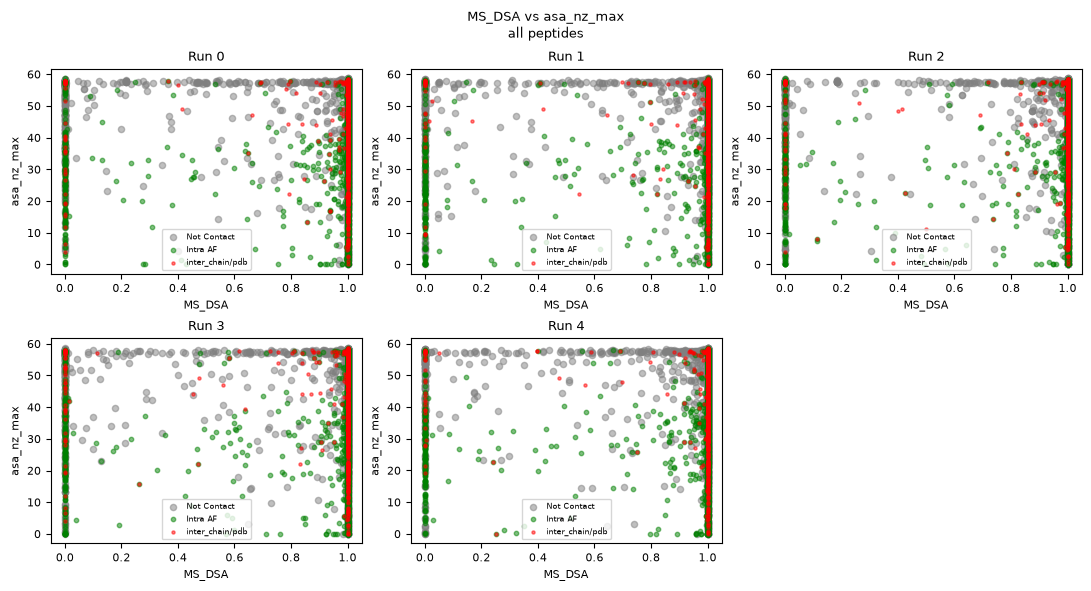

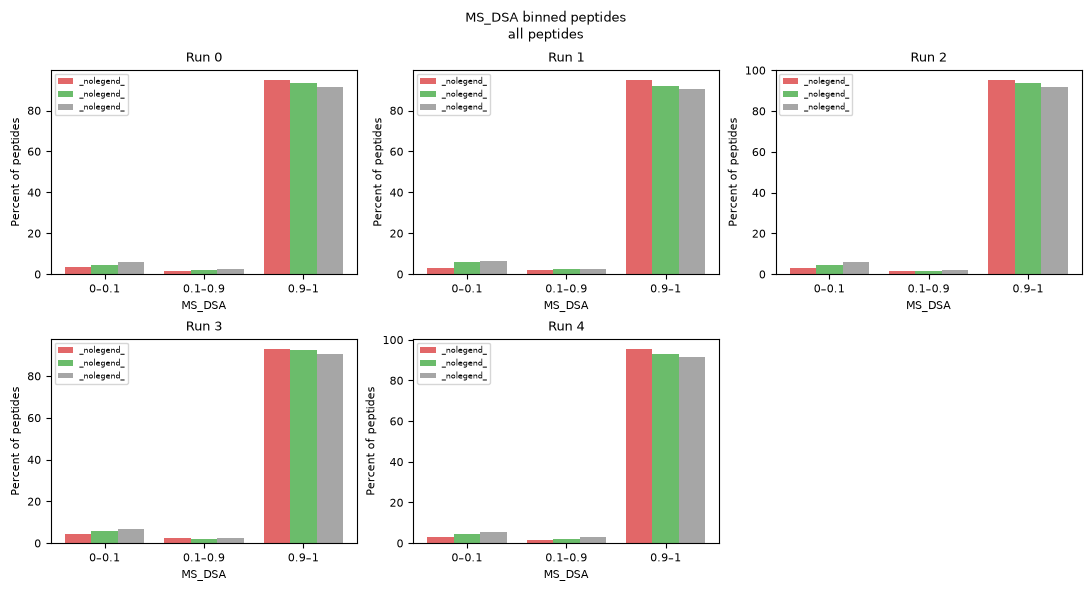

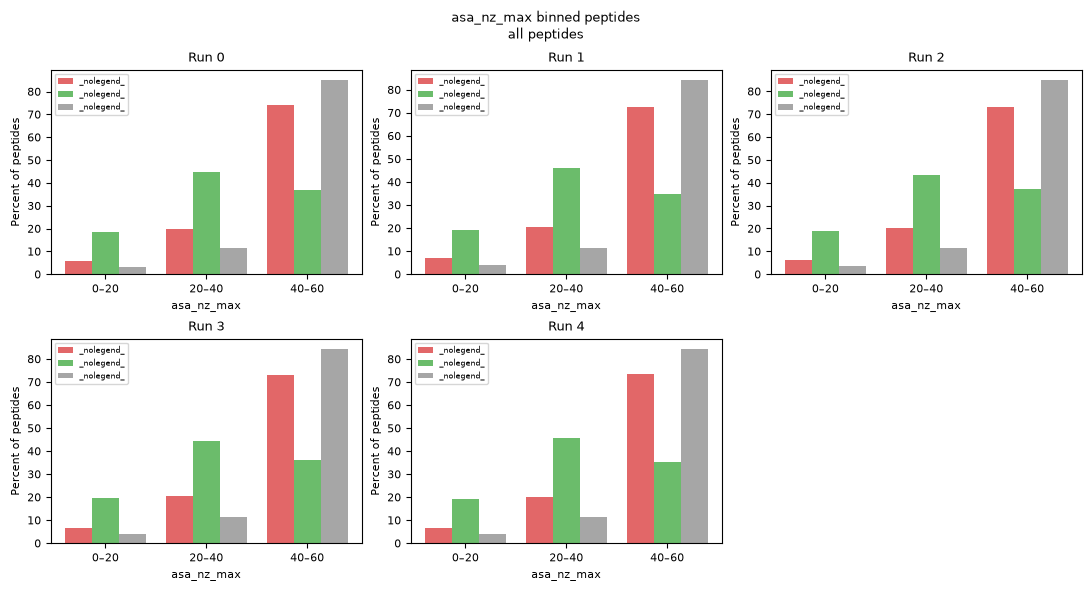

In [3]:
common = dict(bond_type=bond_type, strict=strict, exclude=exclude)
plot_runs(ms_dsa_by_run, plot_dsa_vs_sasa_with_binding_annotation, sasa_column=sasa_column, dsa_column=dsa_column, **common)
plt.show()
plot_runs(ms_dsa_by_run, binned_histogram, column=dsa_column, bins=dsa_bins, **common)
plt.show()
plot_runs(ms_dsa_by_run, binned_histogram, column=sasa_column, bins=sasa_bins, **common)
plt.show()

## 2. `MS_DSA_shared_charges`, both channels observed and non-zero shared areas

Excludes `channel_absent`, `no_shared_charges` and `zero_area_shared`: only peptides whose shared charge states
have a non-zero area in both channels (MS_DSA strictly between 0 and 1).

Inter PDB: 72 rows  (0.278 with MS_DSA_shared_charges < 0.9)
Intra PDB: 185 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra AF: 203 rows  (0.404 with MS_DSA_shared_charges < 0.9)
Not contact: 432 rows  (0.426 with MS_DSA_shared_charges < 0.9)
Inter PDB: 57 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra PDB: 170 rows  (0.388 with MS_DSA_shared_charges < 0.9)
Intra AF: 179 rows  (0.447 with MS_DSA_shared_charges < 0.9)
Not contact: 380 rows  (0.445 with MS_DSA_shared_charges < 0.9)
Inter PDB: 69 rows  (0.275 with MS_DSA_shared_charges < 0.9)
Intra PDB: 189 rows  (0.365 with MS_DSA_shared_charges < 0.9)
Intra AF: 178 rows  (0.433 with MS_DSA_shared_charges < 0.9)
Not contact: 387 rows  (0.390 with MS_DSA_shared_charges < 0.9)
Inter PDB: 75 rows  (0.387 with MS_DSA_shared_charges < 0.9)
Intra PDB: 203 rows  (0.379 with MS_DSA_shared_charges < 0.9)
Intra AF: 202 rows  (0.411 with MS_DSA_shared_charges < 0.9)
Not contact: 406 rows  (0.441 with MS_DSA_shared_charges < 0.9)
Inter PD

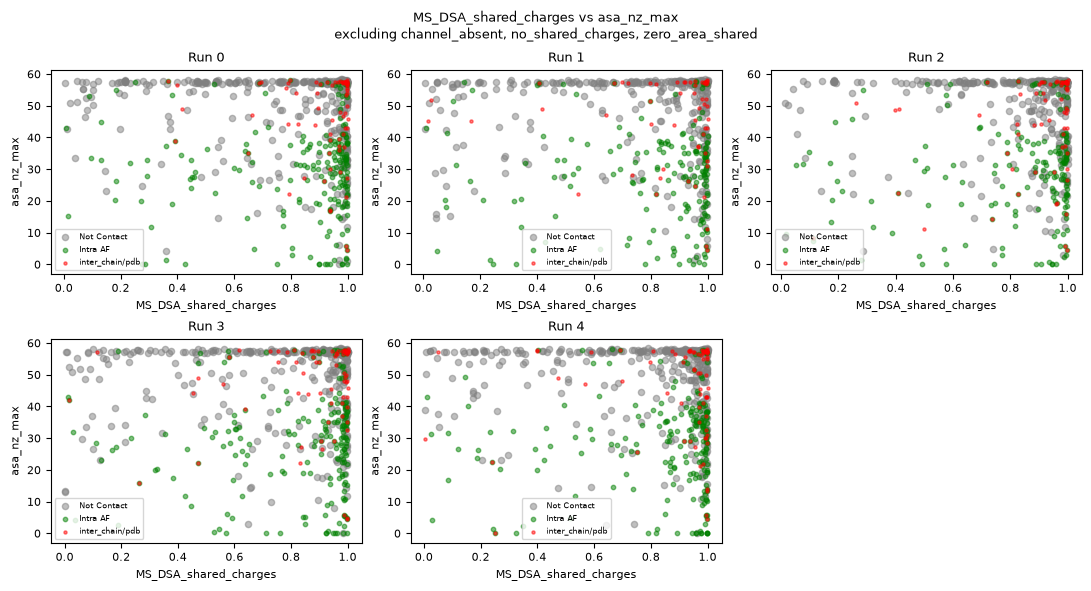

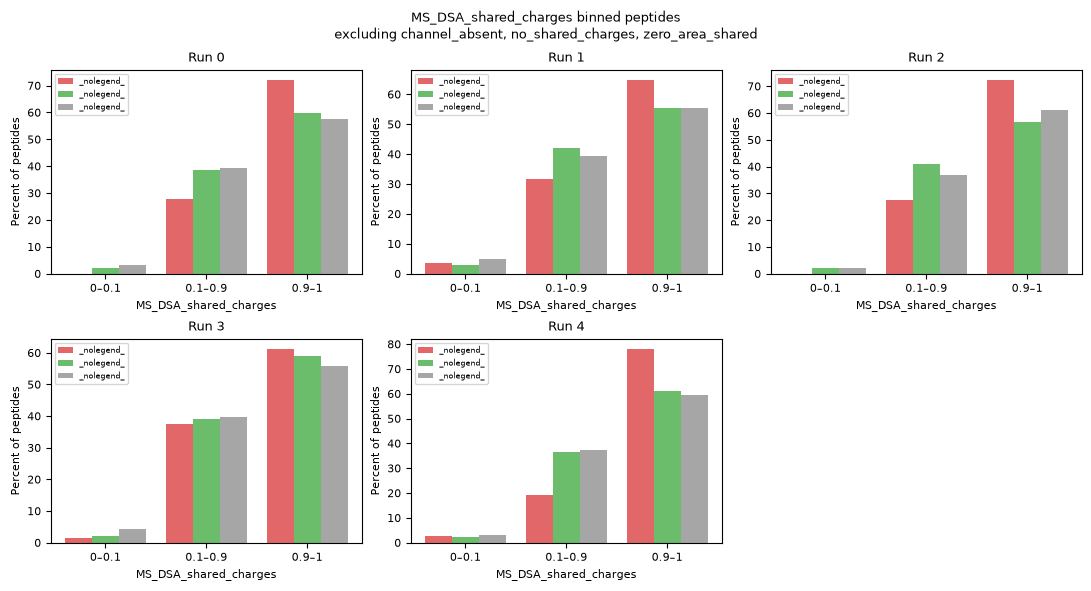

In [4]:
common = dict(bond_type=bond_type, strict=strict, exclude=["channel_absent", "no_shared_charges", "zero_area_shared"])
plot_runs(ms_dsa_by_run, plot_dsa_vs_sasa_with_binding_annotation, sasa_column=sasa_column, dsa_column="MS_DSA_shared_charges", **common)
plt.show()
plot_runs(ms_dsa_by_run, binned_histogram, column="MS_DSA_shared_charges", bins=dsa_bins, **common)
plt.show()

## 3. Both channels observed (zero areas allowed), for `MS_DSA` and `MS_DSA_shared_charges`

Excludes only `channel_absent`: every peptide has a row in both the light and the heavy channel, but one channel
may have zero area (`zero_area` / `zero_area_shared`, MS_DSA = 0 or 1).
`MS_DSA_shared_charges` is additionally NaN (not plotted) when the channels share no charge state (`no_shared_charges`).

Run 0, MS_DSA: 1589 peptides with both channels observed, 844 of them with a zero area
Run 1, MS_DSA: 1463 peptides with both channels observed, 789 of them with a zero area
Run 2, MS_DSA: 1372 peptides with both channels observed, 687 of them with a zero area
Run 3, MS_DSA: 1461 peptides with both channels observed, 733 of them with a zero area
Run 4, MS_DSA: 1846 peptides with both channels observed, 1052 of them with a zero area
Inter PDB: 167 rows  (0.136 with MS_DSA < 0.9)
Intra PDB: 455 rows  (0.171 with MS_DSA < 0.9)
Intra AF: 508 rows  (0.191 with MS_DSA < 0.9)
Not contact: 943 rows  (0.220 with MS_DSA < 0.9)
Inter PDB: 140 rows  (0.191 with MS_DSA < 0.9)
Intra PDB: 389 rows  (0.209 with MS_DSA < 0.9)
Intra AF: 427 rows  (0.241 with MS_DSA < 0.9)
Not contact: 880 rows  (0.219 with MS_DSA < 0.9)
Inter PDB: 166 rows  (0.141 with MS_DSA < 0.9)
Intra PDB: 420 rows  (0.190 with MS_DSA < 0.9)
Intra AF: 413 rows  (0.222 with MS_DSA < 0.9)
Not contact: 778 rows  (0.220 with MS_DSA < 0.

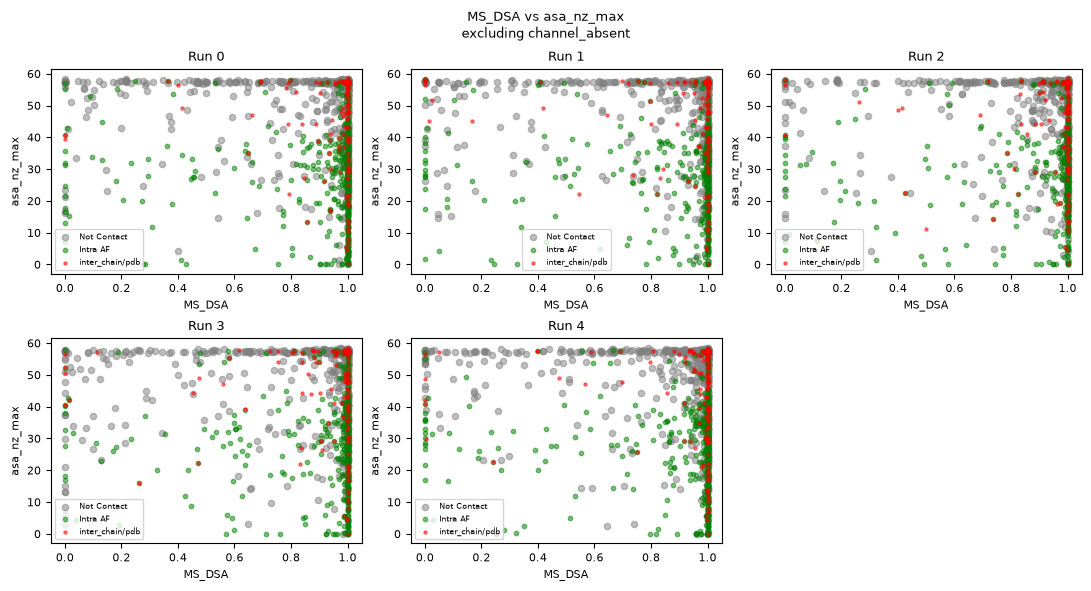

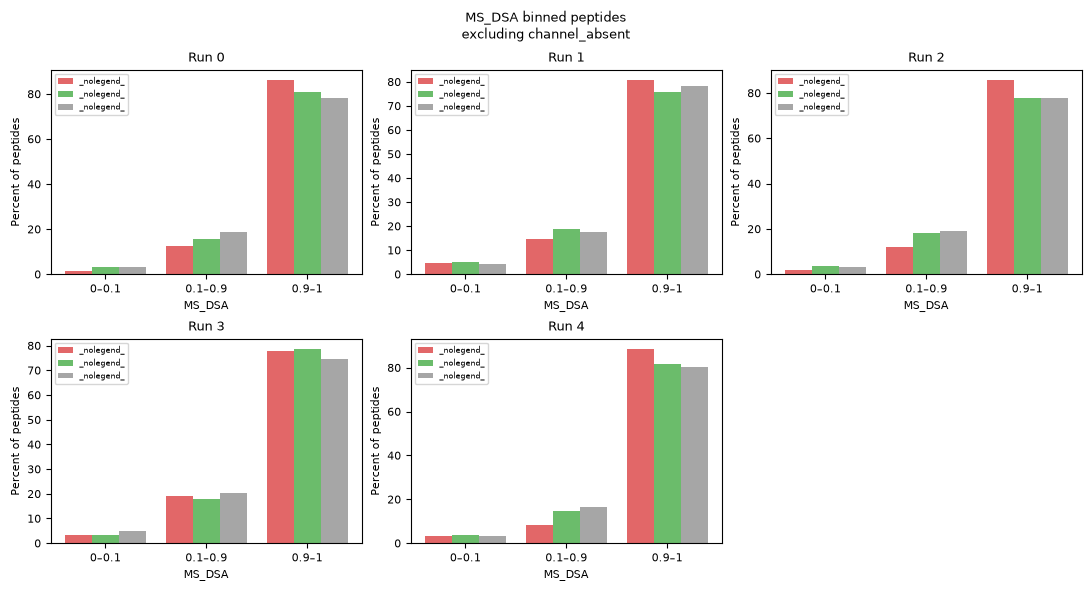

Run 0, MS_DSA_shared_charges: 1580 peptides with both channels observed, 838 of them with a zero area
Run 1, MS_DSA_shared_charges: 1456 peptides with both channels observed, 788 of them with a zero area
Run 2, MS_DSA_shared_charges: 1361 peptides with both channels observed, 686 of them with a zero area
Run 3, MS_DSA_shared_charges: 1455 peptides with both channels observed, 734 of them with a zero area
Run 4, MS_DSA_shared_charges: 1840 peptides with both channels observed, 1056 of them with a zero area


Inter PDB: 167 rows  (0.144 with MS_DSA_shared_charges < 0.9)
Intra PDB: 455 rows  (0.178 with MS_DSA_shared_charges < 0.9)
Intra AF: 508 rows  (0.199 with MS_DSA_shared_charges < 0.9)
Not contact: 943 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Inter PDB: 140 rows  (0.185 with MS_DSA_shared_charges < 0.9)
Intra PDB: 389 rows  (0.212 with MS_DSA_shared_charges < 0.9)
Intra AF: 427 rows  (0.240 with MS_DSA_shared_charges < 0.9)
Not contact: 880 rows  (0.220 with MS_DSA_shared_charges < 0.9)
Inter PDB: 166 rows  (0.142 with MS_DSA_shared_charges < 0.9)
Intra PDB: 420 rows  (0.196 with MS_DSA_shared_charges < 0.9)
Intra AF: 413 rows  (0.223 with MS_DSA_shared_charges < 0.9)
Not contact: 778 rows  (0.225 with MS_DSA_shared_charges < 0.9)
Inter PDB: 156 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Intra PDB: 425 rows  (0.206 with MS_DSA_shared_charges < 0.9)
Intra AF: 461 rows  (0.215 with MS_DSA_shared_charges < 0.9)
Not contact: 829 rows  (0.255 with MS_DSA_shared_charges < 0.9)
Inte

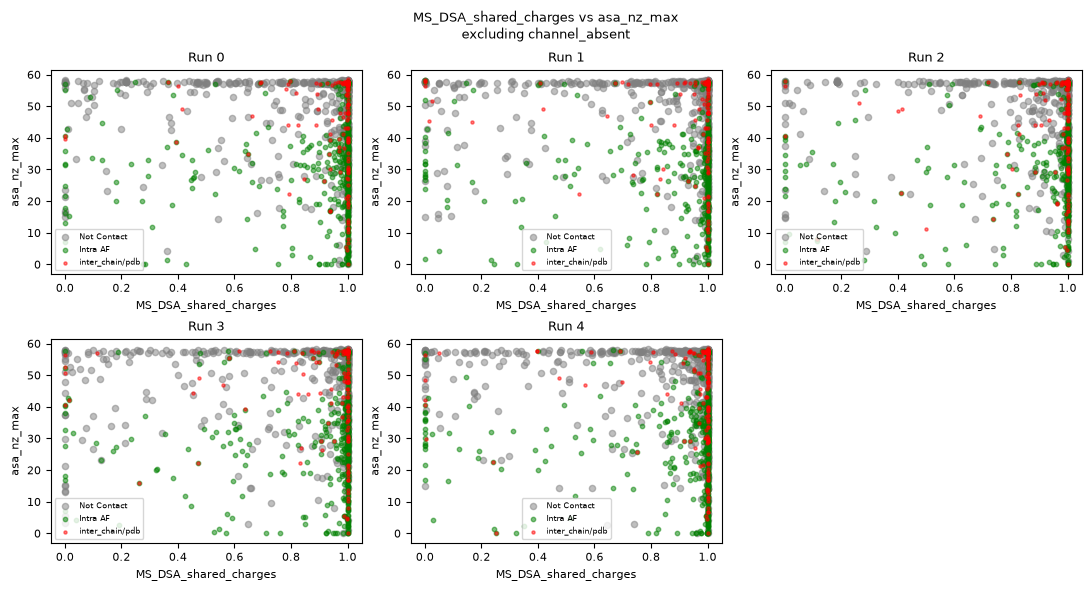

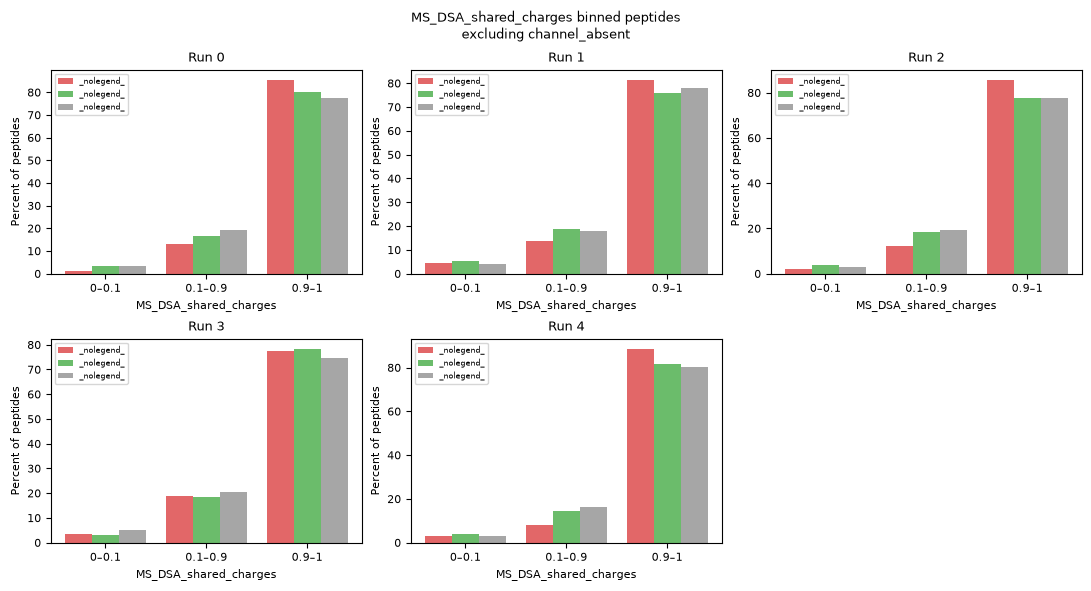

In [5]:
common = dict(bond_type=bond_type, strict=strict, exclude=["channel_absent"])
for column, zero_flag in [("MS_DSA", "zero_area"), ("MS_DSA_shared_charges", "zero_area_shared")]:
    for run_index, ms_dsa in ms_dsa_by_run.items():
        both = ms_dsa[~ms_dsa["channel_absent"] & ms_dsa[column].notna()]
        print(f"Run {run_index}, {column}: {len(both)} peptides with both channels observed, {int(both[zero_flag].sum())} of them with a zero area")
    plot_runs(ms_dsa_by_run, plot_dsa_vs_sasa_with_binding_annotation, sasa_column=sasa_column, dsa_column=column, **common)
    plt.show()
    plot_runs(ms_dsa_by_run, binned_histogram, column=column, bins=dsa_bins, **common)
    plt.show()